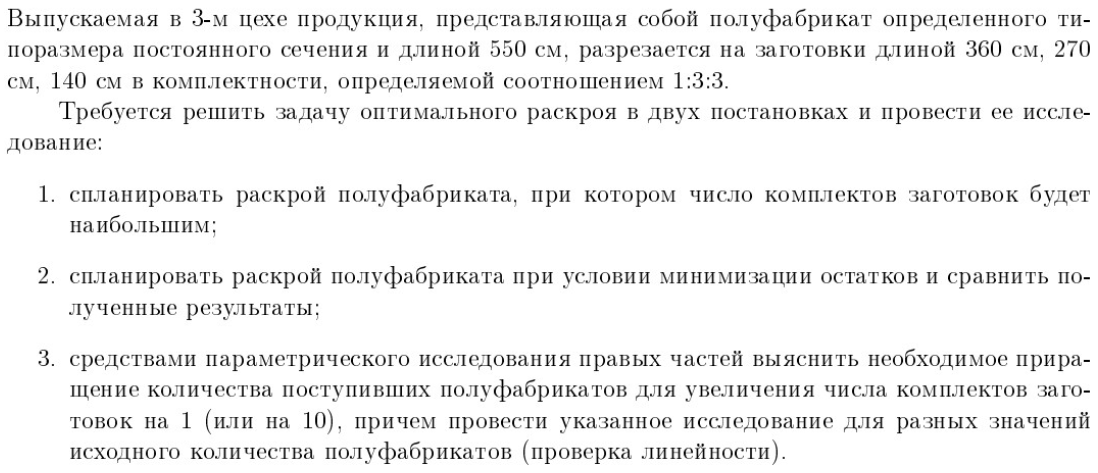

Постановка задачи  
Имеется полуфабрикат длиной 550 см.  
Из него изготавливаются заготовки трёх типов: 360 см, 270 см, 140 см.  
Требуется сделать раскрой полуфабрикатов таким образом, чтобы обеспечить выпуск комплектов заготовок в соотношении 1:3:3.  
Постановка 1 - максимальное число комплектов.  
Постановка 2 - минимальное число остатков.  
Рассмотрим возможные варианты раскроя. Каждая карта раскроя $p$ задаётся тройкой $(a,b,c)$, где: 

$a$ - количество заготовок 360 см,  
$b$ - количество заготовок 270 см,  
$c$ - количество заготовок 140 см  
И при этом верно неравенство $360a + 270b + 140c \leq 550$

Введём переменную $x_p \geq 0$ - количество использования карты раскроя p.  
Все карты раскроя будут в множестве $P$.
Теперь можно записать условие для комплекта. Найдём количество всех заготовок.

$\sum_{i=0}^{len P}(a_i * x_i)$ - количество произведённых заготовок длиной 360см,  
$\sum_{i=0}^{len P}(b_i * x_i)$ - количество произведённых заготовок длиной 270см,  
$\sum_{i=0}^{len P}(c_i * x_i)$ - количество произведённых заготовок длиной 140см.  

Пусть z - количество полных комплектов заготовок. Тогда должна быть справедлива система:

\begin{cases}
\sum_{i=0}^{len P}(a_i * x_i) \geq z\\
\sum_{i=0}^{len P}(b_i * x_i) \geq 3z\\
\sum_{i=0}^{len P}(c_i * x_i) \geq 3z
\end{cases}
Целевая функция $F$. Постановка_1 - максимизация количества комплектов, то есть максимизация функции $F$.

In [50]:
L = 550
P = []
for a in range(0, L//360+1):
    for b in range(0, L//270+1):
        for c in range(0, L//140+1):
            s = a*360 + b*270 + c*140
            if 0 < s <= 550:
                waste = L - s
                P.append((a,b,c,waste))
print("Выполнено")

Выполнено


In [58]:
import pulp

def solution(n):
    F = pulp.LpProblem("Постановка_1", pulp.LpMaximize)
    N = n
    
    x = pulp.LpVariable.dicts("x", range(len(P)), lowBound=0, cat="Integer")
    z = pulp.LpVariable("z", lowBound=0, cat="Integer")
    
    F += pulp.lpSum(P[i][0] * x[i] for i in range(len(P))) >= z
    F += pulp.lpSum(P[i][1] * x[i] for i in range(len(P))) >= 3*z
    F += pulp.lpSum(P[i][2] * x[i] for i in range(len(P))) >= 3*z
    F += pulp.lpSum(x[i] for i in range(len(P))) <= N
    F += z
    
    F.solve()
    return (pulp.value(z), sum(x[i].varValue*P[i][3] for i in range(len(P))))

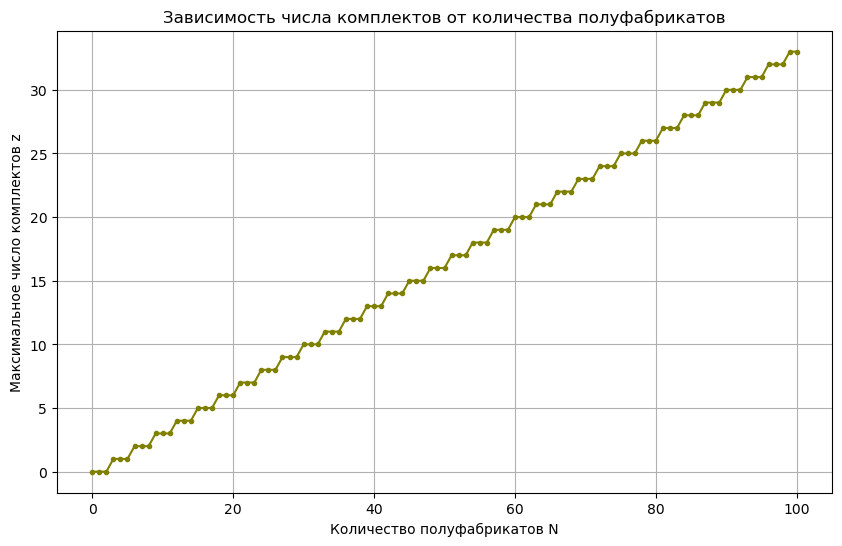

In [59]:
import matplotlib.pyplot as plt

N_values = range(0,100+1)
z_values = []
waste_values = []
for N in N_values:
    z_values.append(int(solution(N)[0]))
    waste_values.append(solution(N)[1])
    
plt.figure(figsize=(10, 6))
plt.plot(N_values, z_values, marker='.', color='olive')
plt.xlabel("Количество полуфабрикатов N")
plt.ylabel("Максимальное число комплектов z")
plt.title("Зависимость числа комплектов от количества полуфабрикатов")

plt.grid(True)

plt.show()

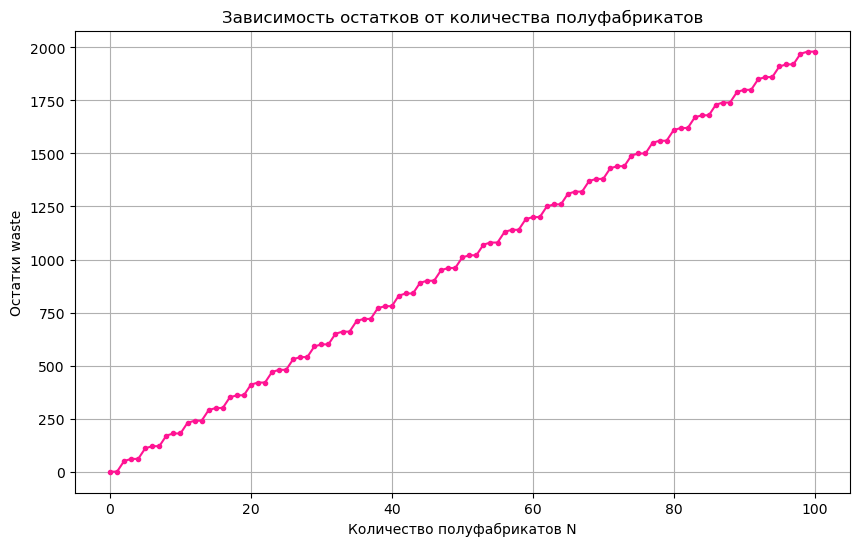

In [60]:
plt.figure(figsize=(10, 6))
plt.plot(N_values, waste_values, marker='.', color = 'deeppink')
plt.xlabel("Количество полуфабрикатов N")
plt.ylabel("Остатки waste")
plt.title("Зависимость остатков от количества полуфабрикатов")

plt.grid(True)

plt.show()

In [61]:
def solution2(n, z_fix):
    F = pulp.LpProblem("Постановка_2", pulp.LpMinimize)
    N = n
    
    x = pulp.LpVariable.dicts("x", range(len(P)), lowBound=0, cat="Integer")
    z = pulp.LpVariable("z", lowBound=0, cat="Integer")
    
    F += pulp.lpSum(P[i][0] * x[i] for i in range(len(P))) >= z
    F += pulp.lpSum(P[i][1] * x[i] for i in range(len(P))) >= 3*z
    F += pulp.lpSum(P[i][2] * x[i] for i in range(len(P))) >= 3*z
    F += pulp.lpSum(x[i] for i in range(len(P))) <= N
    F += z == z_fix
    F += pulp.lpSum(P[i][3]*x[i] for i in range(len(P)))

    F.solve()
    return pulp.value(F.objective)

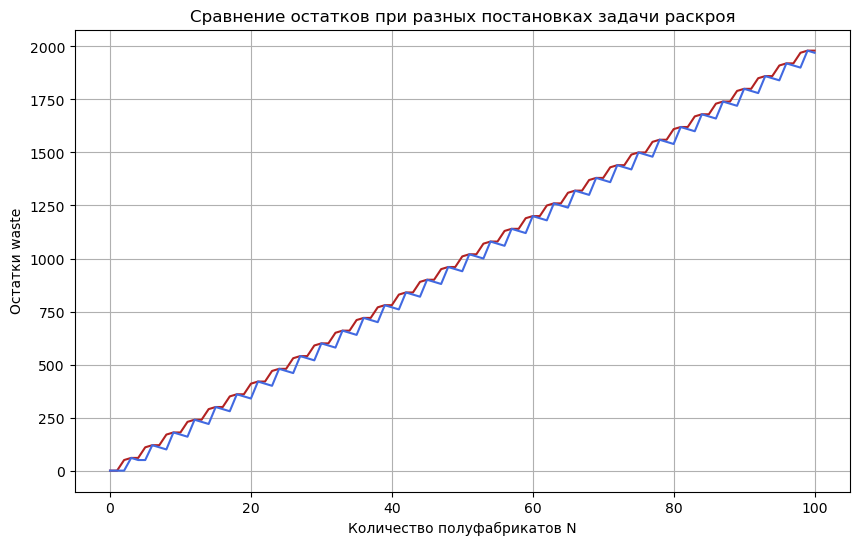

In [62]:
N_values = range(0,101)
min_waste_values = []
for N in N_values:
    z = solution(N)[0]
    min_waste_values.append(solution2(N,z))
plt.figure(figsize=(10, 6))
plt.plot(n_values, waste_values, color='firebrick')
plt.plot(n_values, min_waste_values, color='royalblue')
plt.xlabel("Количество полуфабрикатов N")
plt.ylabel("Остатки waste")
plt.title("Сравнение остатков при разных постановках задачи раскроя")

plt.grid(True)

plt.show()